In [4]:
import pandas as pd
import joblib

df = pd.read_csv("../data/processed/ddos_clean.csv")

X = df.drop("Label", axis=1)

model = joblib.load("../models/ddos_xgb_v1.pkl")

In [7]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance.head(20)

,feature,importance
8,Fwd Packet Length Mean,0.594049
4,Total Length of Fwd Packets,0.375154
35,Bwd Header Length,0.004184
21,Fwd IAT Mean,0.003180
12,Bwd Packet Length Mean,0.002941
48,URG Flag Count,0.002501
43,FIN Flag Count,0.001831
37,Bwd Packets/s,0.001759
77,Idle Min,0.001752
0,Destination Port,0.001473


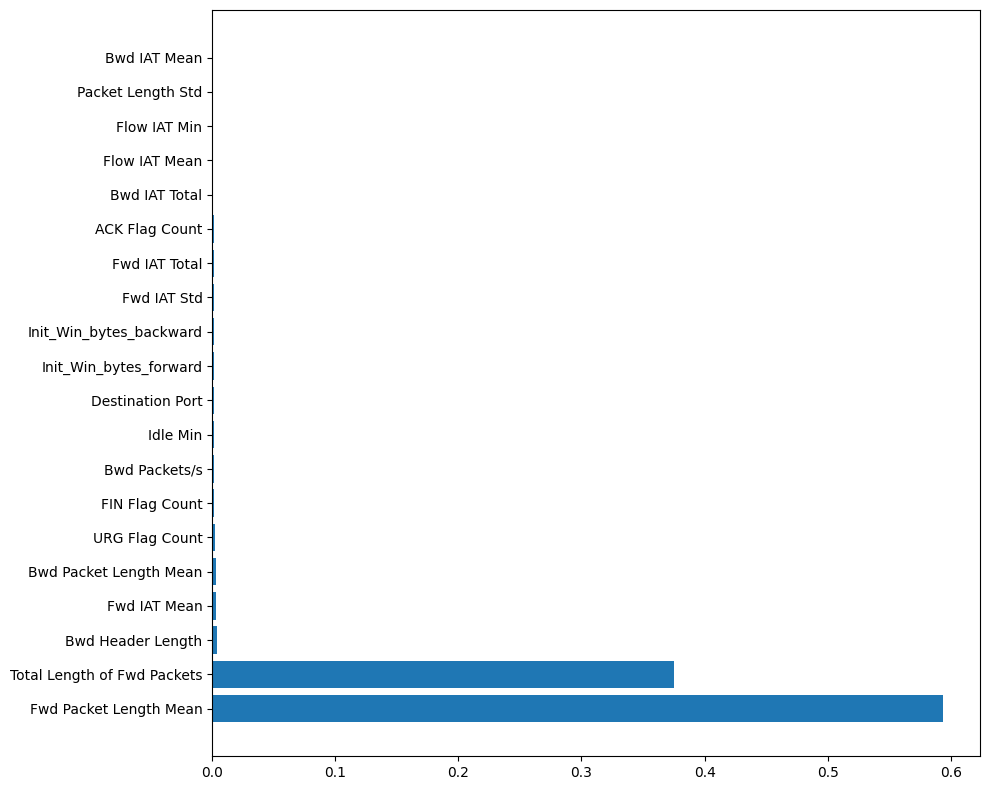

In [8]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["feature"],
    top20["importance"]
)

plt.tight_layout()

plt.show()

In [9]:
import joblib

joblib.dump(
    model,
    "../models/ddos_xgb_v1.pkl"
)

['../models/ddos_xgb_v1.pkl']